## Partie CNN

# Initialisation pour Colab

In [5]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [6]:
import sys
my_local_drive='/content/gdrive/My Drive/Colab Notebooks/ML_FDS'
sys.path.append(my_local_drive)

In [7]:
%cd $my_local_drive


/content/gdrive/My Drive/Colab Notebooks/ML_FDS


Importation des librairies
---



In [8]:
import os
import pandas as pd
import re
import numpy as np
import random
import zipfile
import requests
import io
import time
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split, StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.models import load_model
from tensorflow.keras.metrics import Mean
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.utils import image_dataset_from_directory

from tensorflow.keras.utils import to_categorical

from tensorflow.keras import regularizers

from sklearn.metrics import classification_report, confusion_matrix,  ConfusionMatrixDisplay

import csv


# Pour utiliser au mieux le GPU
AUTOTUNE = tf.data.AUTOTUNE

# Fonctions, classes et variables utiles pour la suite

In [9]:
def get_default_params(
        dataset_dir="./flickr_subset2",
        model_dir="./models_forclip",
        figures_dir="figures") -> dict:
    # returns a dictionary with all the parameters
    # parameters can be modified
    train_dir = os.path.join(dataset_dir, "train_data")
    val_dir = os.path.join(dataset_dir, "val_data")
    test_dir = os.path.join(dataset_dir, "test_data")

    train_image_dir = os.path.join(train_dir, "images")
    val_image_dir = os.path.join(val_dir, "images")
    test_image_dir = os.path.join(test_dir, "images")

    image_size = (224, 224)

    param_dict = {
        "model_dir": model_dir,
        "dataset_dir": dataset_dir,
        "figures_dir": figures_dir,
        "train_dir": train_dir,
        "train_image_dir": train_image_dir,

        "save_model_with_architecture": True,

        "val_dir": val_dir,
        "val_image_dir": val_image_dir,

        "test_dir": test_dir,
        "test_image_dir": test_image_dir,

        # model training parameters
        # Attention respecter bien l'ordre alphabétique des classes pour
        # le générateur
        "class_names": ['ball', 'bike', 'dog', 'water'],
        # class encoding dict
        "class_dict": {
            "ball": 0,
            "bike": 1,
            "dog": 2,
            "water": 3
        },
        # Pour les images
        "image_size": image_size,
        "image_shape": image_size + (3,),

        "learning_rate": 1e-3,
        "data_augmentation": True,

        # pour le training:
        "patience": 10,
        "batch_size": 32,
        "nb_epochs": 40,
    }

    return param_dict


In [10]:
param_dict = get_default_params()


# Partie classification d'images

La cellule suivante affiche quelques images pour vous faire une idée de ce que vous manipulez.   

**Remarque :** n'hésitez pas à aller regarder comment les images sont obtenues pour les afficher ...

**Remarques :**
- Les images sont en couleurs et ont une taille de 224x224. Cela veut dire qu'elles prennent beaucoup de place et qu'il n'est pas possible de les charger directement en mémoire pour l'apprentissage ou la validation. Il est donc indispensable de les envoyer à la volée, i.e. par batches. **Astuce :** Chercher dans les guides comment faire pour envoyer les images à la volée à partir d'un répertoire.
- L'entraînement du modèle peut être long aussi il est préférable de le sauvegarder au fur et à mesure. Pour cela dans la cellule ci-dessous vous trouverez une autre fonction callback : `ModelCheckpoint`. Elle sauvegarde à chaque epoch dans model_path (qui est initialisé en début de cellule) le modèle Keras avec les meilleurs poids. Vous verrez que la mesure suivie est la val_loss. Si elle s'améliore le modèle est sauvegardé. L'avantage est qu'en cas de problème vous aurez toujours une version sauvegardé.
- Pour votre loss, vous pourrez utiliser `loss="categorical_crossentropy`. Comme optimizer, utiliser `optimizer="adam`.    

**Conseil :** l'apprentissage d'un modèle peut être très long. Il est important avant de mettre un trop grand nombre d'epochs de vérifier que la sauvegarde de votre modèle est bien réalisée et que vous pouvez le recharger. Il n'y a rien de pire que d'attendre des heures et de se rendre compte qu'on a mal sauvegardé le modèle et qu'il faut tout recommencer !!! Normalement ici les fonctions (correspondant aux couches) utilisées sont "*built-in*", i.e. Keras les connait et ne posera pas de problèmes, il sait les sérialiser. Par contre dès que vous allez devoir définir des couches plus personnalisées il va falloir penser à mettre des *décorateurs* qui préciseront comment sérialiser le modèle pour le sauvegarder. Cela sera très utile pour la suite. Vous pouvez voir dans la partie classe utile pour la suite des exemples de décorateur (e.g `@tf.keras.utils.register_keras_serializable()`).  

In [11]:
!ls ./flickr_subset2/

captions      captions.gsheet  __MACOSX   train_data  vocab.txt
captions.csv  images	       test_data  val_data


Définition du modèle CNN

In [12]:
def define_model(image_shape, number_of_classes, learning_rate=1e-3):
  input = Input(shape=image_shape)

  convolution_layer1 = Conv2D(filters=32, kernel_size=3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(0.001))(input)
  max_pooling_layer1 = MaxPooling2D(pool_size=(2, 2))(convolution_layer1)

  convolution_layer2 = Conv2D(filters=64, kernel_size=3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(0.001))(max_pooling_layer1)
  max_pooling_layer2 = MaxPooling2D(pool_size=(2, 2))(convolution_layer2)

  convolution_layer3 = Conv2D(filters=128, kernel_size=3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(0.001))(max_pooling_layer2)
  max_pooling_layer3 = MaxPooling2D(pool_size=(2, 2))(convolution_layer3)

  flatten_layer = Flatten()(max_pooling_layer3)

  dense1 = Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001))(flatten_layer)

  output = Dense(number_of_classes, activation="softmax")(dense1)

  model = Model(inputs=input, outputs=output, name="cnn_minimal")
  model.compile(optimizer=Adam(learning_rate),
                loss="categorical_crossentropy",
                metrics=["accuracy", keras.metrics.F1Score(average='macro')])

  model.summary()

  return model

In [13]:
def plot_history_loss_f1(history, save_filepath=None):
    """
    Trace côte à côte les courbes Loss et F1-score (train/val si dispo)
    à partir d'un objet Keras History.
    """
    hist = history.history

    # --- gestion des différentes clés possibles pour le F1 ---
    f1_key = None
    val_f1_key = None

    for k in ["f1_score", "f1"]:
        if k in hist:
            f1_key = k
            break

    for k in ["val_f1_score", "val_f1"]:
        if k in hist:
            val_f1_key = k
            break

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss ---
    if "loss" in hist:
        axes[0].plot(hist["loss"], label="train")
    if "val_loss" in hist:
        axes[0].plot(hist["val_loss"], label="val")

    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend(loc="upper right")

    # --- F1-score ---
    if f1_key is not None:
        axes[1].plot(hist[f1_key], label="train")
        if val_f1_key is not None:
            axes[1].plot(hist[val_f1_key], label="val")

        axes[1].set_title("F1-score")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("F1-score")
        axes[1].legend(loc="lower right")
    else:
        axes[1].set_visible(False)  # pas de F1 → on masque

    plt.tight_layout()

    # --- Save File Logic ---
    if save_filepath and isinstance(save_filepath, str):
        try:
            plt.savefig(save_filepath)
            print(f"Plot saved to: {save_filepath}")
        except Exception as e:
            print(f"Error saving plot to {save_filepath}: {e}")

    plt.show()

In [14]:
def plot_history_simple(history, save_filepath=None):
    """
    Trace côte à côte les courbes Loss et Accuracy (train/val si dispo)
    à partir d'un objet Keras History.
    """
    hist = history.history

    # compatibilité anciennes versions ("acc"/"val_acc")
    acc_key = "accuracy" if "accuracy" in hist else "acc"
    val_acc_key = "val_accuracy" if "val_accuracy" in hist else "val_acc"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss ---
    if "loss" in hist:
        axes[0].plot(hist["loss"], label="train")
    if "val_loss" in hist:
        axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend(loc='lower left')

    # --- Accuracy ---
    if acc_key in hist:
        axes[1].plot(hist[acc_key], label="train")
        if val_acc_key in hist:
            axes[1].plot(hist[val_acc_key], label="val")
        axes[1].set_title("Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend(loc="lower left")
    else:
        axes[1].set_visible(False)  # si pas d'accuracy, on masque le 2e plot

    plt.tight_layout()

    # --- Save File Logic ---
    if save_filepath and isinstance(save_filepath, str):
        try:
            plt.savefig(save_filepath)
            print(f"Plot saved to: {save_filepath}")
        except Exception as e:
            print(f"Error saving plot to {save_filepath}: {e}")

    plt.show()

def save_history_csv(history, filename):
    """save history as csv file"""
    history_dict = history.history
    keys = history_dict.keys()  # headers
    rows = zip(*history_dict.values())  # values

    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(keys)
        writer.writerows(rows)

## Entrainement du modèle CNN


In [15]:
# TRAIN AND SAVE
def train_model(
        model_config: dict,  # dict with all params (loaded from load_default_params),
        model_name: str,  # basename of the model
        ):
    full_model_name = "_".join([
        model_name,
        str(model_config['nb_epochs']),
        "epochs"
    ])

    save_dir = model_config["model_dir"]
    model = define_model(model_config["image_shape"], len(model_config["class_names"]), model_config["learning_rate"])

    save_name_model = f"{model_name}.weights.h5"
    save_model_path = os.path.join(save_dir, save_name_model)

    # Entraînement
    epochs = model_config["nb_epochs"]

    # Generation d'images à la volée à partir d'un répertoire

    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomFlip("vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(height_factor=(-0.2, 0.2), width_factor=(-0.2, 0.2)),
        layers.RandomContrast(0.3),
        layers.RandomBrightness(0.3),
    ])

    train_dataset = image_dataset_from_directory(
        model_config["train_image_dir"],
        image_size=model_config["image_size"],
        batch_size=model_config["batch_size"],
        shuffle=True,
        seed=5
    )

    validation_dataset = image_dataset_from_directory(
        model_config["val_image_dir"],
        image_size=model_config["image_size"],
        batch_size=model_config["batch_size"],
        shuffle=False
    )

    class_names = model_config["class_names"]  # class names from the dataset
    train_dataset = train_dataset.map(lambda image, label: (data_augmentation(image, training=True), label))

    number_of_classes = len(class_names)

    # Normalize images

    train_dataset = train_dataset.map(lambda image, label: (tf.cast(image/255. ,tf.float32), label))
    validation_dataset = validation_dataset.map(lambda image, label: (tf.cast(image/255. ,tf.float32), label))

    def to_one_hot(image, label):
        label = tf.one_hot(label, depth=number_of_classes)
        return image, label

    train_dataset = train_dataset.map(to_one_hot)
    validation_dataset = validation_dataset.map(to_one_hot)

    callbacks = [
        EarlyStopping(
            monitor="val_loss",      # ou "val_accuracy"
            patience=model_config["patience"],             # nb d'epochs sans amélioration avant arrêt
            min_delta=0.001,           # amélioration minimale à considérer
            mode="min",              # "min" pour une loss, "max" pour une accuracy
            restore_best_weights=True,
            verbose=1
          ),
        ModelCheckpoint(
            save_model_path,
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=True
        )
    ]

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    # save history
    history_filename =f"{model_name}_history.csv"

    # Courbes loss/accuracy
    plot_history_simple(history)

    if model_config["save_model_with_architecture"]:
      # Model with architecture
      name_model_with_architecture = f"{full_model_name}.keras"
      model_with_architecture_path = os.path.join(save_dir, name_model_with_architecture)

      # Save model with architecture
      print(f"Saving full model to {model_with_architecture_path}...")
      model.save(model_with_architecture_path)

    # save history
    history_filename = os.path.join(save_dir, f"{full_model_name}_history.csv")
    save_history_csv(history, history_filename)

    return history

In [16]:
model_name = "cnn_final4"

history = train_model(param_dict, model_name)

save_file_path = os.path.join(param_dict["figures_dir"], model_name + "_history.png")
plot_history_loss_f1(history, save_filepath=save_file_path)

Model: "cnn_minimal"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,948 (49.36 MB)

 Trainable params: 12,938,948 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Found 486 files belonging to 4 classes.
Found 54 files belonging to 4 classes.
Epoch 1/40


KeyboardInterrupt: 

## Evaluation du modèle

In [17]:
model = load_model(os.path.join(param_dict['model_dir'], 'cnn_final4_40_epochs.keras'))

In [20]:
def eval_model(model, model_config, model_name):
  test_dataset = image_dataset_from_directory(
    model_config["test_image_dir"],
    image_size=model_config["image_size"],
    batch_size=model_config["batch_size"],
    shuffle=False
  )


  test_dataset = test_dataset.map(lambda image, label: (tf.cast(image/255. ,tf.float32), label))

  y_true = []
  y_pred = []

  for images, labels in test_dataset:
    y_true.extend(labels.numpy())

    preds = model.predict(images, verbose=0)

    predicted_classes = np.argmax(preds, axis=-1)
    y_pred.extend(predicted_classes)

  y_true = np.array(y_true)
  y_pred = np.array(y_pred)

  class_names = param_dict['class_names']

  print(classification_report(y_true, y_pred))
  ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=class_names).plot()

  save_path = os.path.join(model_config['figures_dir'], f"{model_name}_confusion_matrix.png")
  plt.savefig(save_path, dpi=300, bbox_inches="tight")

Found 60 files belonging to 4 classes.
              precision    recall  f1-score   support

           0       0.40      0.13      0.20        15
           1       0.67      0.27      0.38        15
           2       0.33      0.27      0.30        15
           3       0.32      0.80      0.46        15

    accuracy                           0.37        60
   macro avg       0.43      0.37      0.33        60
weighted avg       0.43      0.37      0.33        60



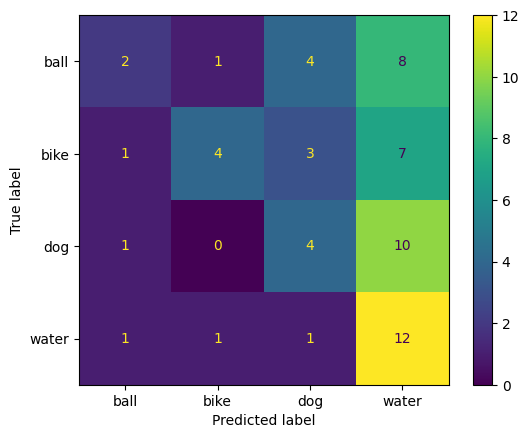

In [21]:
eval_model(model, param_dict, 'cnn_final4_40_epochs.keras')